In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

/Volumes/Jagdeep/Projects/Chatbot/venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

In [5]:
llm=init_chat_model("groq:openai/gpt-oss-120b")

In [6]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10f9bf230>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f9bfcb0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def chatbot(state: State):
    return {"messages":[llm.invoke(state['messages'])]}

In [8]:
graph_builder=StateGraph(State)

graph_builder.add_node('llmchatbot', chatbot)
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

graph=graph_builder.compile()

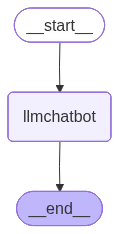

In [9]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
response=graph.invoke({"messages": "Hi"})
print(response)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='548ba8d3-00f4-4b33-af9d-1b1bcc430b8c'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond with a friendly greeting. No special policies triggered. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 72, 'total_tokens': 114, 'completion_time': 0.090929335, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.013850095, 'prompt_tokens_details': None, 'queue_time': 0.009296747, 'total_time': 0.10477943}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6fb4303df4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca617-5c90-7621-9e73-69a83699f9c3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 42, 'total_tokens': 114, 'output_token_det

In [11]:
print(response['messages'][-1].content)

Hello! How can I help you today?


In [12]:
for event in graph.stream({'messages':'Hi, how are you?'}):
    for value in event.values():
        print(value['messages'][-1].content)

Hello! I'm doing great, thank you for asking. How can I assist you today?


In [16]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
result=tool.invoke("What is langgraph")

In [27]:
print("Result1:", result['results'][0]['content'])
print("Result2:", result['results'][1]['content'])

Result1: LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decision-making by modeling complex relationships between nodes, which means it uses AI agents to analyze their past actions and feedback. **LLM applications**: By using LangGraph’s capabilities, developers can build more sophistic

In [28]:
def multiply(a: int, b: int)-> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: a * b
    """
    return a * b

In [29]:
tools=[tool, multiply]

In [30]:
llm_with_tool=llm.bind_tools(tools)

In [31]:
from langgraph.prebuilt import ToolNode, tools_condition

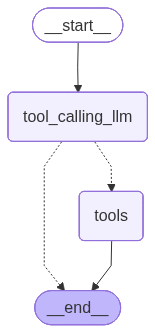

In [33]:
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [35]:
response=graph.invoke({'messages': 'What is the recent news with Sam Altman?'})

In [41]:
response['messages'][-1].content

'{"query": "Sam Altman recent news 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://disconnect.blog/sam-altmans-anti-human-worldview/", "title": "Sam Altman\'s anti-human worldview - Disconnect Blog", "content": "In early 2024, he declared we would need to geoengineer the planet to mitigate the climate impacts of all the energy needed to allow him and the tech industry", "score": 0.7279179, "raw_content": null}, {"url": "https://thehill.com/policy/technology/5758898-altman-backs-anthropic-pentagon-stand/", "title": "Altman says OpenAI agrees with Anthropic\'s red lines in Pentagon ...", "content": "OpenAI CEO Sam Altman supports Anthropic\'s \\"red lines\\" in negotiations with the Pentagon over AI model usage: refusing to allow mass surveillance and", "score": 0.33587396, "raw_content": null}], "response_time": 1.46, "request_id": "30e53469-2a28-498e-9a95-0575e2c8f7a3"}'

In [42]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent news with Sam Altman?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b045a0e5-5347-46e9-bdb8-e1f284581fdc)
 Call ID: fc_b045a0e5-5347-46e9-bdb8-e1f284581fdc
  Args:
    query: Sam Altman recent news 2024
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "Sam Altman recent news 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://disconnect.blog/sam-altmans-anti-human-worldview/", "title": "Sam Altman's anti-human worldview - Disconnect Blog", "content": "In early 2024, he declared we would need to geoengineer the planet to mitigate the climate impacts of all the energy needed to allow him and the tech industry", "score": 0.7279179, "raw_content": null}, {"url": "https://t

In [43]:
response1=graph.invoke({'messages': 'What is 2 multiply by 3?'})

In [45]:
print(response1)

{'messages': [HumanMessage(content='What is 2 multiply by 3?', additional_kwargs={}, response_metadata={}, id='e810255e-65a7-4e35-ab92-8e58ee112701'), AIMessage(content='2\u202f×\u202f3\u202f=\u202f6.', additional_kwargs={'reasoning_content': 'User asks "What is 2 multiply by 3?" Simple multiplication: 2 * 3 = 6. No need to call function. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 351, 'total_tokens': 404, 'completion_time': 0.110260886, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.016694978, 'prompt_tokens_details': None, 'queue_time': 0.005003419, 'total_time': 0.126955864}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c652c0ffaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca74d-f9d2-7032-8365-48cffa4e0fdb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 351, 'output_tokens': 53, 'total_token

In [44]:
for m in response1['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3?
================================== Ai Message ==================================

2 × 3 = 6.


# ReAct Agent Architecture